In [1]:
# ============================================================
# TownscapeBench v0.1 open-data pilot benchmark
# Open-data demonstration using OSMnx, OpenStreetMap features,
# optional OpenTopography/NASADEM, GeoPandas and Matplotlib.
# ============================================================

import sys
import subprocess
from pathlib import Path

required = [
    "osmnx",
    "geopandas",
    "pandas",
    "numpy",
    "shapely",
    "matplotlib",
    "rasterio",
    "rasterstats",
    "requests",
    "networkx",
    "pyproj"
]

for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import os
import math
import warnings
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import rasterio
from rasterstats import zonal_stats
from shapely.geometry import Polygon, Point, LineString, MultiPolygon
from shapely.ops import unary_union

warnings.filterwarnings("ignore")

ox.settings.use_cache = True
ox.settings.log_console = True
ox.settings.timeout = 180

In [2]:
# ============================================================
# Study area settings
# ============================================================

PLACE_NAME = "Brickfields, Kuala Lumpur, Malaysia"

# Hex size in metres. Use 200 or 250 for district-scale townscape analysis.
HEX_SIZE_M = 250

OUT_DIR = Path("TownscapeBench_outputs")
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
GEO_DIR = OUT_DIR / "geojson"

for d in [FIG_DIR, TAB_DIR, GEO_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Output folder:", OUT_DIR.resolve())

Output folder: C:\Users\Dell\TownscapeBench_outputs


In [3]:
# ============================================================
# Helper functions
# ============================================================

def get_osm_features(poly_wgs84, tags):
    """
    Robust wrapper for OSMnx v1/v2 feature download.
    """
    try:
        return ox.features_from_polygon(poly_wgs84, tags)
    except AttributeError:
        return ox.features.features_from_polygon(poly_wgs84, tags)
    except Exception as e:
        print(f"OSM feature download failed for tags {tags}: {e}")
        return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")


def clean_gdf(gdf, target_crs):
    """
    Clean and project GeoDataFrame.
    """
    if gdf is None or len(gdf) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=target_crs)

    gdf = gdf.reset_index(drop=True)
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")

    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf["geometry"] = gdf.geometry.make_valid()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf.to_crs(target_crs)


def polygon_only(gdf):
    if gdf is None or len(gdf) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=gdf.crs if gdf is not None else None)
    return gdf[gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()


def line_only(gdf):
    if gdf is None or len(gdf) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=gdf.crs if gdf is not None else None)
    return gdf[gdf.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()


def point_or_centroid(gdf):
    if gdf is None or len(gdf) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=gdf.crs if gdf is not None else None)

    out = gdf.copy()
    out["geometry"] = out.geometry.apply(
        lambda geom: geom if geom.geom_type in ["Point", "MultiPoint"] else geom.centroid
    )
    return out


def make_hex_grid(boundary_gdf, hex_size):
    """
    Create hexagonal grid clipped to boundary.
    hex_size is approximate hex radius in metres.
    """
    boundary_geom = boundary_gdf.geometry.iloc[0]
    minx, miny, maxx, maxy = boundary_geom.bounds

    dx = hex_size * 3 / 2
    dy = math.sqrt(3) * hex_size

    hexes = []
    x = minx - dx
    col = 0

    while x < maxx + dx:
        y = miny - dy
        offset = (dy / 2) if col % 2 else 0

        while y < maxy + dy:
            yc = y + offset
            angles = np.linspace(0, 2 * np.pi, 7)[:-1]
            coords = [(x + hex_size * np.cos(a), yc + hex_size * np.sin(a)) for a in angles]
            hex_poly = Polygon(coords)

            if hex_poly.intersects(boundary_geom):
                hexes.append(hex_poly.intersection(boundary_geom))

            y += dy

        x += dx
        col += 1

    grid = gpd.GeoDataFrame({"grid_id": range(1, len(hexes) + 1)}, geometry=hexes, crs=boundary_gdf.crs)
    grid["hex_area_m2"] = grid.geometry.area
    return grid


def area_sum_by_hex(grid, polygons, out_col):
    """
    Area of polygon features inside each hex.
    """
    grid[out_col] = 0.0

    if polygons is None or len(polygons) == 0:
        return grid

    polygons = polygon_only(polygons)
    if len(polygons) == 0:
        return grid

    inter = gpd.overlay(
        grid[["grid_id", "geometry"]],
        polygons[["geometry"]],
        how="intersection",
        keep_geom_type=False
    )

    if len(inter) == 0:
        return grid

    inter["area_m2"] = inter.geometry.area
    vals = inter.groupby("grid_id")["area_m2"].sum()
    grid[out_col] = grid["grid_id"].map(vals).fillna(0.0)
    return grid


def line_length_by_hex(grid, lines, out_col):
    """
    Length of line features inside each hex.
    """
    grid[out_col] = 0.0

    if lines is None or len(lines) == 0:
        return grid

    lines = line_only(lines)
    if len(lines) == 0:
        return grid

    inter = gpd.overlay(
        grid[["grid_id", "geometry"]],
        lines[["geometry"]],
        how="intersection",
        keep_geom_type=False
    )

    if len(inter) == 0:
        return grid

    inter["length_m"] = inter.geometry.length
    vals = inter.groupby("grid_id")["length_m"].sum()
    grid[out_col] = grid["grid_id"].map(vals).fillna(0.0)
    return grid


def point_count_by_hex(grid, points, out_col):
    """
    Count point or centroid features inside each hex.
    """
    grid[out_col] = 0

    if points is None or len(points) == 0:
        return grid

    pts = point_or_centroid(points)
    joined = gpd.sjoin(
        pts[["geometry"]],
        grid[["grid_id", "geometry"]],
        predicate="within",
        how="inner"
    )

    if len(joined) == 0:
        return grid

    vals = joined.groupby("grid_id").size()
    grid[out_col] = grid["grid_id"].map(vals).fillna(0).astype(int)
    return grid


def normalise(series):
    """
    Min-max normalise; returns 0 if no variation.
    """
    s = pd.Series(series).astype(float)
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())


def shannon_entropy(row, cols):
    vals = np.array([row[c] for c in cols], dtype=float)
    total = vals.sum()
    if total == 0:
        return 0
    p = vals / total
    p = p[p > 0]
    return -np.sum(p * np.log(p))


def add_north_arrow(ax, x=0.95, y=0.95, size=18):
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y - 0.10),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=size,
        fontweight="bold",
        arrowprops=dict(arrowstyle="-|>", lw=1.5, color="black")
    )


def add_scale_bar(ax, length_m=None, location=(0.08, 0.06), linewidth=3):
    """
    Draw a simple scale bar in projected CRS metres.
    """
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    width = xlim[1] - xlim[0]

    if length_m is None:
        target = width / 5
        nice_lengths = np.array([50, 100, 200, 250, 500, 1000, 2000, 5000])
        length_m = nice_lengths[np.argmin(np.abs(nice_lengths - target))]

    x0 = xlim[0] + location[0] * width
    y0 = ylim[0] + location[1] * (ylim[1] - ylim[0])

    ax.plot([x0, x0 + length_m], [y0, y0], color="black", lw=linewidth)
    ax.text(
        x0 + length_m / 2,
        y0 + 0.025 * (ylim[1] - ylim[0]),
        f"{int(length_m)} m",
        ha="center",
        va="bottom",
        fontsize=9
    )


def plot_attribute_map(grid, boundary, column, title, filename, overlays=None, cmap="viridis"):
    """
    Plot choropleth map with boundary, legend, scale bar and north arrow.
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    grid.plot(
        column=column,
        ax=ax,
        cmap=cmap,
        legend=True,
        edgecolor="white",
        linewidth=0.3,
        missing_kwds={"color": "lightgrey", "label": "No data"}
    )

    boundary.boundary.plot(ax=ax, color="black", linewidth=1.4)

    if overlays:
        for item in overlays:
            gdf = item.get("gdf")
            label = item.get("label", "")
            color = item.get("color", "black")
            linewidth = item.get("linewidth", 1)
            markersize = item.get("markersize", 5)

            if gdf is not None and len(gdf) > 0:
                geom_types = set(gdf.geometry.geom_type)
                if geom_types.intersection({"LineString", "MultiLineString"}):
                    gdf.plot(ax=ax, color=color, linewidth=linewidth, label=label)
                elif geom_types.intersection({"Point", "MultiPoint"}):
                    gdf.plot(ax=ax, color=color, markersize=markersize, label=label)
                else:
                    gdf.boundary.plot(ax=ax, color=color, linewidth=linewidth, label=label)

    add_north_arrow(ax)
    add_scale_bar(ax)

    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_axis_off()

    if overlays:
        ax.legend(loc="lower right", fontsize=8, frameon=True)

    plt.tight_layout()
    out_path = FIG_DIR / filename
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

In [5]:
# ============================================================
# Load study-area boundary and OSM data
# ============================================================

boundary_wgs = ox.geocode_to_gdf(PLACE_NAME)
boundary_wgs = boundary_wgs.to_crs("EPSG:4326")
poly_wgs = boundary_wgs.geometry.iloc[0]

# ============================================================
# Safe projection helpers for different OSMnx versions
# ============================================================

def project_gdf_safe(gdf):
    """
    Project GeoDataFrame to a suitable local UTM CRS.
    Compatible with different OSMnx versions.
    """
    try:
        return ox.projection.project_gdf(gdf)
    except AttributeError:
        try:
            return ox.project_gdf(gdf)
        except AttributeError:
            estimated_crs = gdf.estimate_utm_crs()
            return gdf.to_crs(estimated_crs)


def project_graph_safe(G, to_crs):
    """
    Project OSMnx graph safely across different OSMnx versions.
    """
    try:
        return ox.projection.project_graph(G, to_crs=to_crs)
    except AttributeError:
        return ox.project_graph(G, to_crs=to_crs)


# Estimate local projected CRS
boundary_proj = project_gdf_safe(boundary_wgs)
CRS_PROJ = boundary_proj.crs

print("Projected CRS:", CRS_PROJ)

boundary_proj.to_file(GEO_DIR / "study_area_boundary.geojson", driver="GeoJSON")

# ============================================================
# OSM feature tags
# ============================================================

building_tags = {"building": True}

landuse_tags = {
    "landuse": True,
    "amenity": True,
    "leisure": True,
    "shop": True,
    "tourism": True,
    "historic": True
}

poi_tags = {
    "amenity": True,
    "shop": True,
    "tourism": True,
    "historic": True,
    "leisure": True
}

water_tags = {
    "natural": ["water"],
    "waterway": True,
    "landuse": ["reservoir", "basin"]
}

green_tags = {
    "leisure": ["park", "garden", "playground", "recreation_ground"],
    "landuse": ["grass", "forest", "recreation_ground", "meadow", "orchard"],
    "natural": ["wood", "tree", "scrub", "grassland"]
}

# ============================================================
# Download OSM feature layers
# ============================================================

print("Downloading buildings...")
buildings = clean_gdf(get_osm_features(poly_wgs, building_tags), CRS_PROJ)

print("Downloading land-use / amenities...")
landuse = clean_gdf(get_osm_features(poly_wgs, landuse_tags), CRS_PROJ)

print("Downloading POIs...")
pois = clean_gdf(get_osm_features(poly_wgs, poi_tags), CRS_PROJ)

print("Downloading water features...")
water = clean_gdf(get_osm_features(poly_wgs, water_tags), CRS_PROJ)

print("Downloading vegetation / green features...")
green = clean_gdf(get_osm_features(poly_wgs, green_tags), CRS_PROJ)

print("Downloading walk network...")

try:
    G_walk = ox.graph_from_polygon(poly_wgs, network_type="walk", simplify=True)
except AttributeError:
    G_walk = ox.graph.graph_from_polygon(poly_wgs, network_type="walk", simplify=True)

G_walk = project_graph_safe(G_walk, to_crs=CRS_PROJ)

try:
    nodes, edges = ox.graph_to_gdfs(G_walk)
except AttributeError:
    nodes, edges = ox.convert.graph_to_gdfs(G_walk)

print("Buildings:", len(buildings))
print("Land-use/amenities:", len(landuse))
print("POIs:", len(pois))
print("Water:", len(water))
print("Green:", len(green))
print("Walk edges:", len(edges))
print("Walk nodes:", len(nodes))

Projected CRS: EPSG:32647
Buildings: 509
Land-use/amenities: 469
POIs: 409
Water: 2
Green: 12
Walk edges: 1614
Walk nodes: 575


Number of hex cells: 15
Mean hex area, m2: 67157.89


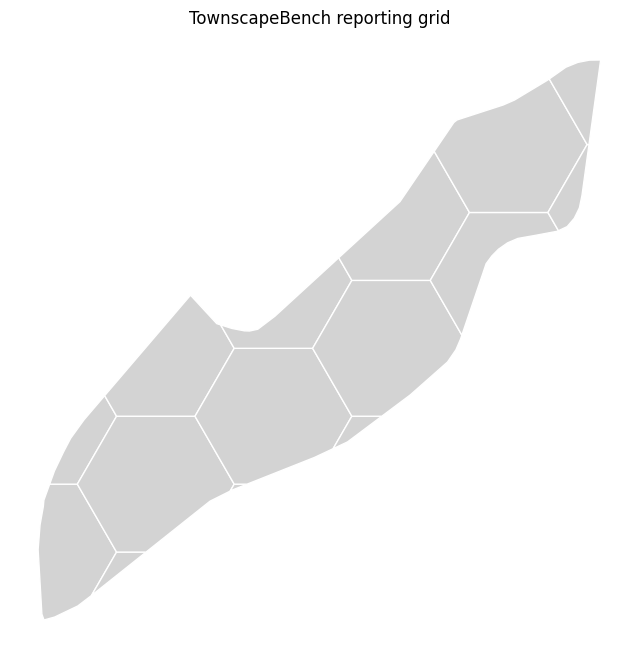

In [6]:
# ============================================================
# Create TownscapeBench spatial reporting units
# ============================================================

grid = make_hex_grid(boundary_proj, HEX_SIZE_M)

print("Number of hex cells:", len(grid))
print("Mean hex area, m2:", round(grid["hex_area_m2"].mean(), 2))

grid.plot(edgecolor="white", facecolor="lightgrey", figsize=(8, 8))
plt.title("TownscapeBench reporting grid")
plt.axis("off")
plt.show()

In [7]:
# ============================================================
# Compute TownscapeBench open-data indicators
# ============================================================

metrics = grid.copy()

# Polygon layers
buildings_poly = polygon_only(buildings)
landuse_poly = polygon_only(landuse)
water_poly = polygon_only(water)
green_poly = polygon_only(green)

# POI points or centroids
pois_pts = point_or_centroid(pois)

# Road edges
road_lines = line_only(edges)

# 1. Building areas
metrics = area_sum_by_hex(metrics, buildings_poly, "building_area_m2")
metrics["building_coverage_ratio"] = metrics["building_area_m2"] / metrics["hex_area_m2"]

# 2. Green / vegetation areas
metrics = area_sum_by_hex(metrics, green_poly, "green_area_m2")
metrics["green_ratio"] = metrics["green_area_m2"] / metrics["hex_area_m2"]

# 3. Water areas
metrics = area_sum_by_hex(metrics, water_poly, "water_area_m2")
metrics["water_ratio"] = metrics["water_area_m2"] / metrics["hex_area_m2"]

# 4. POI density
metrics = point_count_by_hex(metrics, pois_pts, "poi_count")
metrics["poi_density_per_ha"] = metrics["poi_count"] / (metrics["hex_area_m2"] / 10000)

# 5. Building density and grain
building_centroids = buildings_poly.copy()
if len(building_centroids) > 0:
    building_centroids["geometry"] = building_centroids.geometry.centroid

metrics = point_count_by_hex(metrics, building_centroids, "building_count")
metrics["building_density_per_ha"] = metrics["building_count"] / (metrics["hex_area_m2"] / 10000)
metrics["mean_building_footprint_m2"] = np.where(
    metrics["building_count"] > 0,
    metrics["building_area_m2"] / metrics["building_count"],
    0
)

metrics["grain_fineness_index"] = np.where(
    metrics["mean_building_footprint_m2"] > 0,
    1 / metrics["mean_building_footprint_m2"],
    0
)

# 6. Street length density
metrics = line_length_by_hex(metrics, road_lines, "walk_network_length_m")
metrics["walk_network_density_m_per_ha"] = metrics["walk_network_length_m"] / (metrics["hex_area_m2"] / 10000)

# 7. Intersection density
nodes2 = nodes.copy()
if "street_count" in nodes2.columns:
    intersections = nodes2[nodes2["street_count"] >= 3].copy()
else:
    intersections = nodes2.copy()

metrics = point_count_by_hex(metrics, intersections, "intersection_count")
metrics["intersection_density_per_ha"] = metrics["intersection_count"] / (metrics["hex_area_m2"] / 10000)

# 8. Height proxy from building:levels if available
height_col_candidates = ["building:levels", "levels"]
height_col = None
for c in height_col_candidates:
    if c in buildings_poly.columns:
        height_col = c
        break

if height_col is not None and len(buildings_poly) > 0:
    bheight = buildings_poly.copy()
    bheight["levels_num"] = pd.to_numeric(bheight[height_col], errors="coerce")
    bheight["height_proxy_m"] = bheight["levels_num"].fillna(1) * 3.0
    bheight["volume_proxy"] = bheight.geometry.area * bheight["height_proxy_m"]

    inter = gpd.overlay(
        metrics[["grid_id", "geometry"]],
        bheight[["height_proxy_m", "volume_proxy", "geometry"]],
        how="intersection",
        keep_geom_type=False
    )

    if len(inter) > 0:
        inter["area_m2"] = inter.geometry.area
        inter["weighted_height"] = inter["height_proxy_m"] * inter["area_m2"]

        height_mean = inter.groupby("grid_id").apply(
            lambda x: x["weighted_height"].sum() / x["area_m2"].sum()
        )

        volume_sum = inter.groupby("grid_id")["volume_proxy"].sum()

        metrics["mean_height_proxy_m"] = metrics["grid_id"].map(height_mean).fillna(0)
        metrics["fsi_proxy"] = metrics["grid_id"].map(volume_sum).fillna(0) / metrics["hex_area_m2"]
    else:
        metrics["mean_height_proxy_m"] = 0
        metrics["fsi_proxy"] = 0
else:
    metrics["mean_height_proxy_m"] = 0
    metrics["fsi_proxy"] = metrics["building_coverage_ratio"]

# 9. Land-use diversity from broad OSM keys
landuse_pts = point_or_centroid(landuse)

# classify broad class
def classify_osm_row(row):
    txt = " ".join([str(row.get(c, "")) for c in ["landuse", "amenity", "leisure", "shop", "tourism", "historic"]]).lower()

    if any(k in txt for k in ["residential", "apartment"]):
        return "residential"
    if any(k in txt for k in ["retail", "commercial", "shop", "market", "restaurant", "cafe"]):
        return "commercial"
    if any(k in txt for k in ["school", "university", "college", "hospital", "clinic", "place_of_worship"]):
        return "institutional"
    if any(k in txt for k in ["park", "garden", "recreation", "playground", "grass", "forest"]):
        return "green_recreation"
    if any(k in txt for k in ["industrial", "warehouse"]):
        return "industrial"
    return "other"

if len(landuse_pts) > 0:
    landuse_pts["tb_class"] = landuse_pts.apply(classify_osm_row, axis=1)
    joined_lu = gpd.sjoin(
        landuse_pts[["tb_class", "geometry"]],
        metrics[["grid_id", "geometry"]],
        predicate="within",
        how="inner"
    )

    class_counts = pd.crosstab(joined_lu["grid_id"], joined_lu["tb_class"])
    for c in ["residential", "commercial", "institutional", "green_recreation", "industrial", "other"]:
        if c not in class_counts.columns:
            class_counts[c] = 0

    class_counts = class_counts.reset_index()
    metrics = metrics.merge(class_counts, on="grid_id", how="left")

    for c in ["residential", "commercial", "institutional", "green_recreation", "industrial", "other"]:
        metrics[c] = metrics[c].fillna(0)

    lu_cols = ["residential", "commercial", "institutional", "green_recreation", "industrial", "other"]
    metrics["land_use_entropy"] = metrics.apply(lambda r: shannon_entropy(r, lu_cols), axis=1)

else:
    metrics["land_use_entropy"] = 0

# Normalised attribute scores
metrics["context_score"] = normalise(metrics["poi_density_per_ha"] + metrics["building_coverage_ratio"])
metrics["grain_score"] = normalise(metrics["building_density_per_ha"] + metrics["grain_fineness_index"])
metrics["form_score"] = normalise(metrics["building_coverage_ratio"] + metrics["fsi_proxy"] + metrics["mean_height_proxy_m"])
metrics["land_use_score"] = normalise(metrics["land_use_entropy"])
metrics["water_score"] = normalise(metrics["water_ratio"])
metrics["vegetation_score"] = normalise(metrics["green_ratio"])
metrics["public_realm_score"] = normalise(metrics["poi_density_per_ha"] + metrics["green_ratio"])
metrics["connectivity_score"] = normalise(metrics["walk_network_density_m_per_ha"] + metrics["intersection_density_per_ha"])

print(metrics[[
    "grid_id",
    "context_score",
    "grain_score",
    "form_score",
    "land_use_score",
    "water_score",
    "vegetation_score",
    "public_realm_score",
    "connectivity_score"
]].head())

   grid_id  context_score  grain_score  form_score  land_use_score  \
0        1       0.052569     0.125316    0.068370        0.455635   
1        2       0.178077     0.787949    1.000000        0.657081   
2        3       0.128657     0.142363    0.069058        0.000000   
3        4       0.142069     0.255016    0.063604        0.660002   
4        5       0.258015     0.606310    0.137196        0.877756   

   water_score  vegetation_score  public_realm_score  connectivity_score  
0          0.0          1.000000            0.050723            0.221763  
1          0.0          0.000000            0.161488            0.477294  
2          0.0          0.021993            0.122654            0.000000  
3          1.0          0.798996            0.137748            0.489970  
4          0.0          0.000000            0.238851            0.585620  


In [9]:
# ============================================================
# Optional topography: OpenTopography / NASADEM
# ============================================================

OPENTOPO_API_KEY = "Insert Your API Key"  # paste your OpenTopography API key here if available
DEM_TYPE = "NASADEM"   # alternatives include SRTMGL1, SRTMGL3, COP30, COP90 depending on availability
DEM_TIF = OUT_DIR / "nasadem_dem.tif"

def download_opentopography_dem(poly_wgs, out_tif, api_key="", demtype="NASADEM"):
    minx, miny, maxx, maxy = poly_wgs.bounds

    params = {
        "demtype": demtype,
        "south": miny,
        "north": maxy,
        "west": minx,
        "east": maxx,
        "outputFormat": "GTiff"
    }

    if api_key:
        params["API_Key"] = api_key

    url = "https://portal.opentopography.org/API/globaldem"
    r = requests.get(url, params=params, timeout=180)

    if r.status_code != 200:
        raise RuntimeError(f"OpenTopography request failed: {r.status_code} | {r.text[:500]}")

    with open(out_tif, "wb") as f:
        f.write(r.content)

    return out_tif

try:
    if OPENTOPO_API_KEY:
        print("Downloading DEM from OpenTopography...")
        download_opentopography_dem(poly_wgs, DEM_TIF, api_key=OPENTOPO_API_KEY, demtype=DEM_TYPE)
        print("DEM saved:", DEM_TIF)
    else:
        print("No OpenTopography API key provided. Skipping DEM download.")

    if DEM_TIF.exists():
        grid_wgs = metrics.to_crs("EPSG:4326")
        zs = zonal_stats(
            grid_wgs,
            str(DEM_TIF),
            stats=["mean", "std"],
            nodata=None,
            geojson_out=False
        )

        topo_df = pd.DataFrame(zs)
        metrics["elevation_mean_m"] = topo_df["mean"].fillna(0)
        metrics["elevation_std_m"] = topo_df["std"].fillna(0)
        metrics["topography_score"] = normalise(metrics["elevation_mean_m"] + metrics["elevation_std_m"])
    else:
        metrics["elevation_mean_m"] = np.nan
        metrics["elevation_std_m"] = np.nan
        metrics["topography_score"] = np.nan

except Exception as e:
    print("Topography processing failed:", e)
    metrics["elevation_mean_m"] = np.nan
    metrics["elevation_std_m"] = np.nan
    metrics["topography_score"] = np.nan

DEM saved: TownscapeBench_outputs\nasadem_dem.tif


In [10]:
# ============================================================
# Export TownscapeBench metrics
# ============================================================

metrics_out = metrics.copy()

score_cols = [
    "context_score",
    "topography_score",
    "grain_score",
    "form_score",
    "land_use_score",
    "water_score",
    "vegetation_score",
    "public_realm_score",
    "connectivity_score"
]

metric_cols = [
    "grid_id",
    "hex_area_m2",
    "building_area_m2",
    "building_coverage_ratio",
    "building_count",
    "building_density_per_ha",
    "mean_building_footprint_m2",
    "grain_fineness_index",
    "mean_height_proxy_m",
    "fsi_proxy",
    "poi_count",
    "poi_density_per_ha",
    "green_area_m2",
    "green_ratio",
    "water_area_m2",
    "water_ratio",
    "walk_network_length_m",
    "walk_network_density_m_per_ha",
    "intersection_count",
    "intersection_density_per_ha",
    "land_use_entropy",
    "elevation_mean_m",
    "elevation_std_m"
] + score_cols

available_cols = [c for c in metric_cols if c in metrics_out.columns]

metrics_out[available_cols].to_csv(
    TAB_DIR / "townscapebench_metrics_by_hex.csv",
    index=False
)

metrics_out.to_file(
    GEO_DIR / "townscapebench_hex_metrics.geojson",
    driver="GeoJSON"
)

print("Saved metrics table and GeoJSON.")

Saved metrics table and GeoJSON.


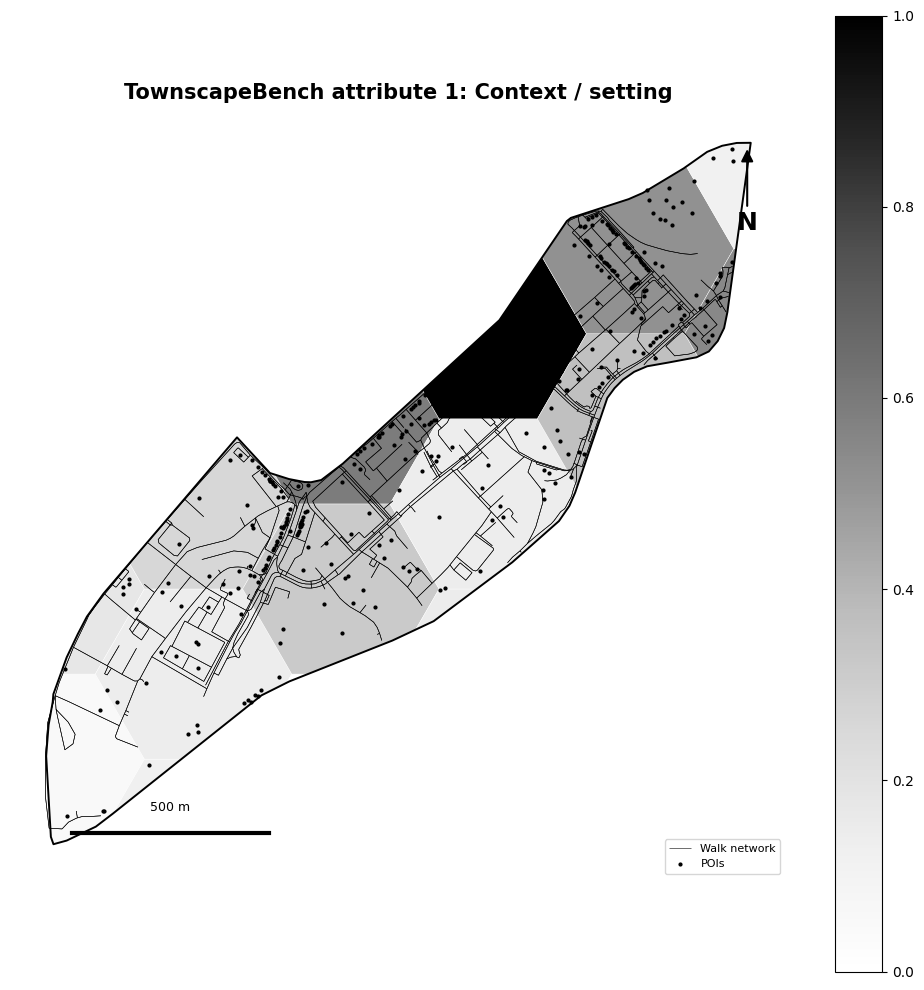

Saved: TownscapeBench_outputs\figures\01_context.png


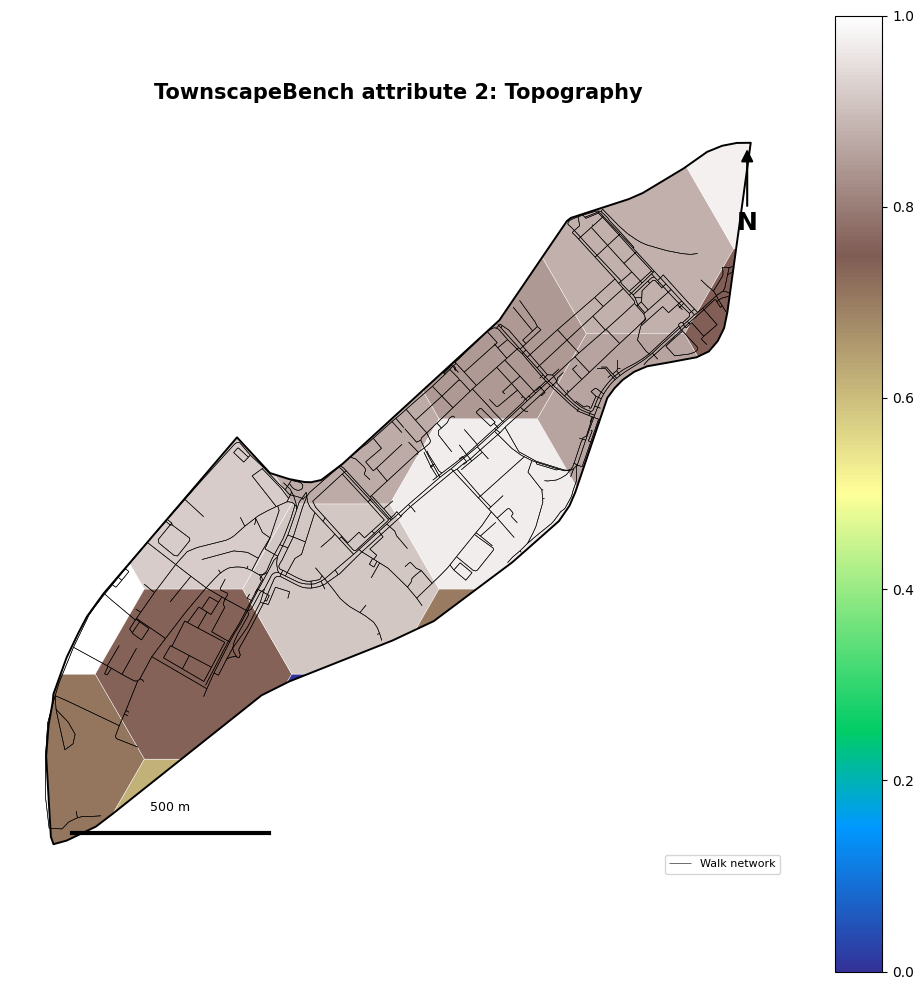

Saved: TownscapeBench_outputs\figures\02_topography.png


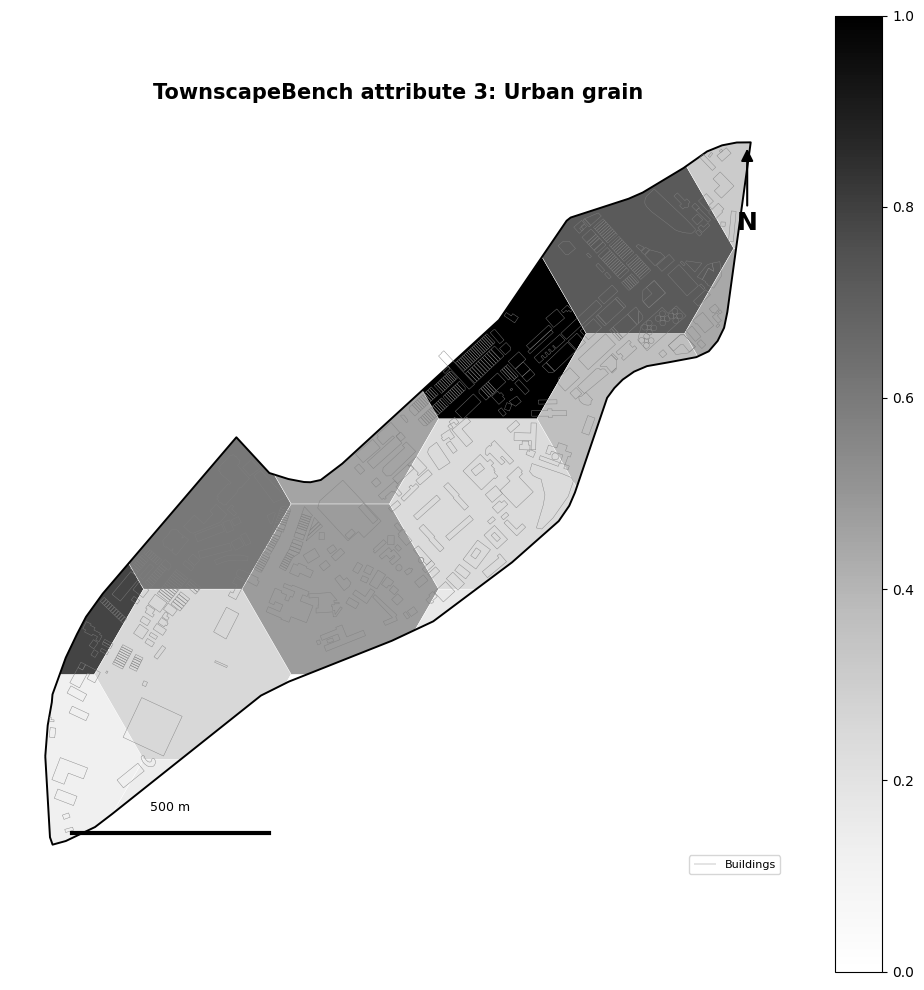

Saved: TownscapeBench_outputs\figures\03_grain.png


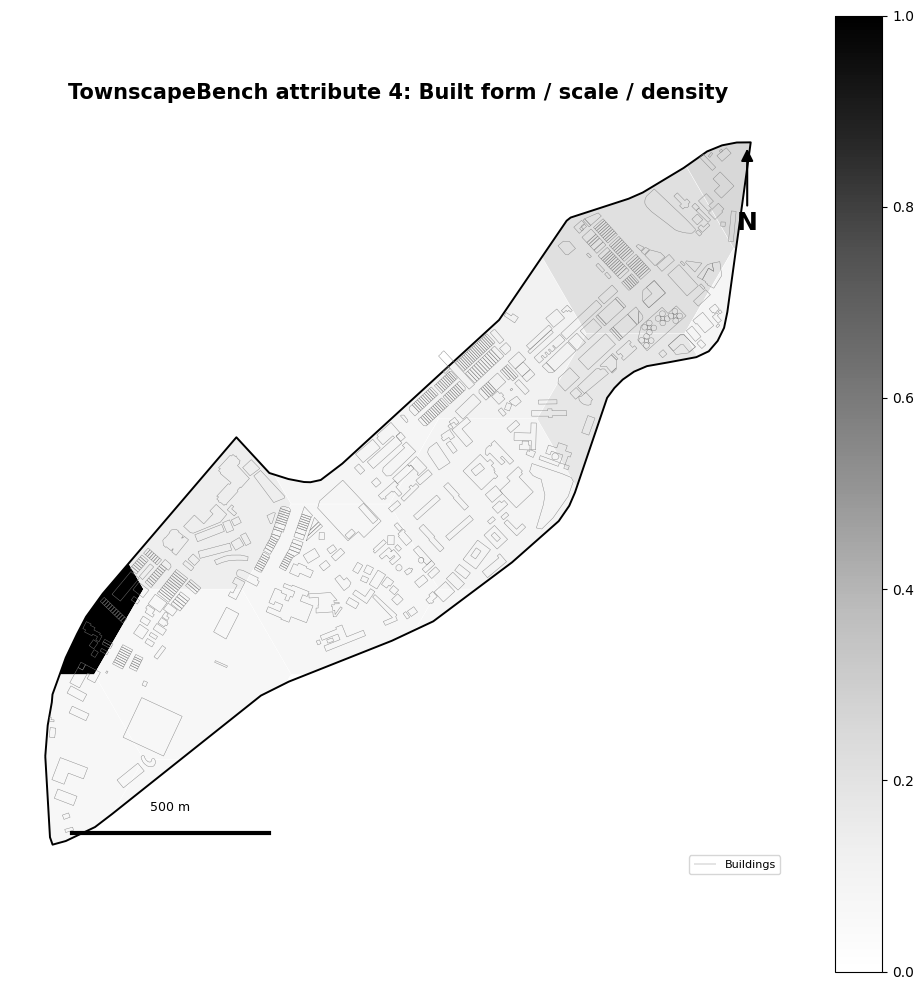

Saved: TownscapeBench_outputs\figures\04_form.png


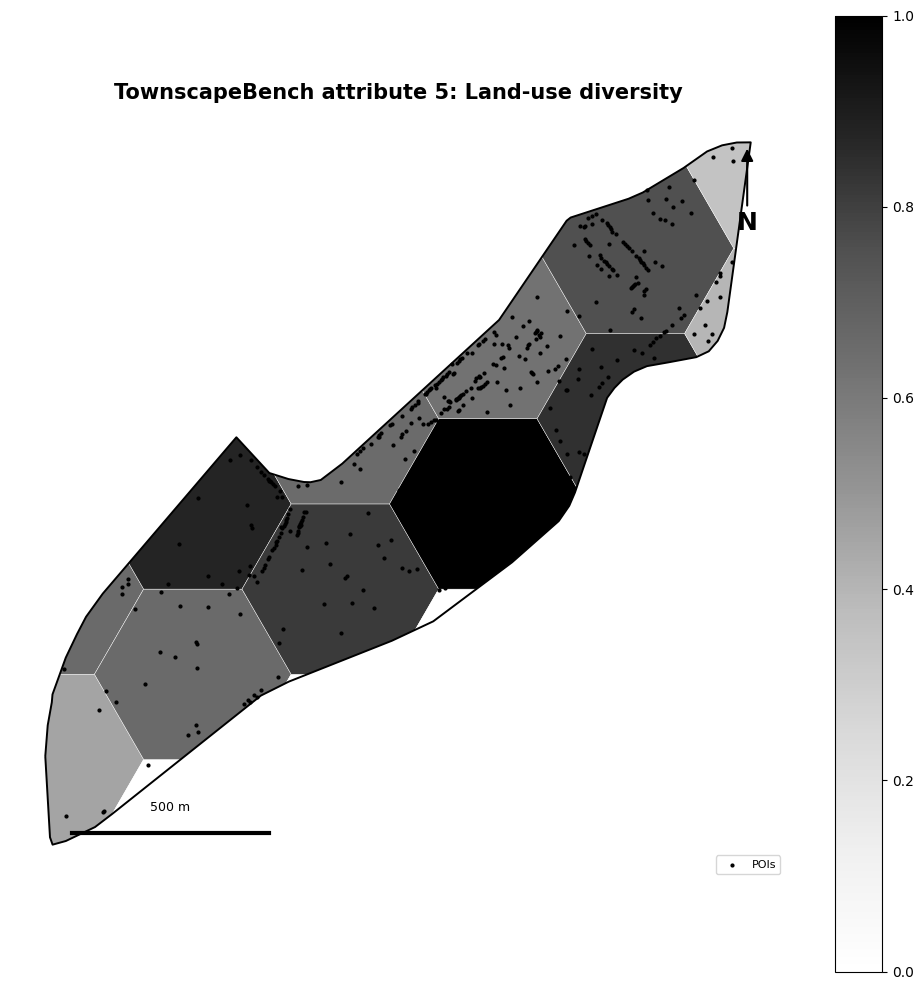

Saved: TownscapeBench_outputs\figures\05_land_use.png


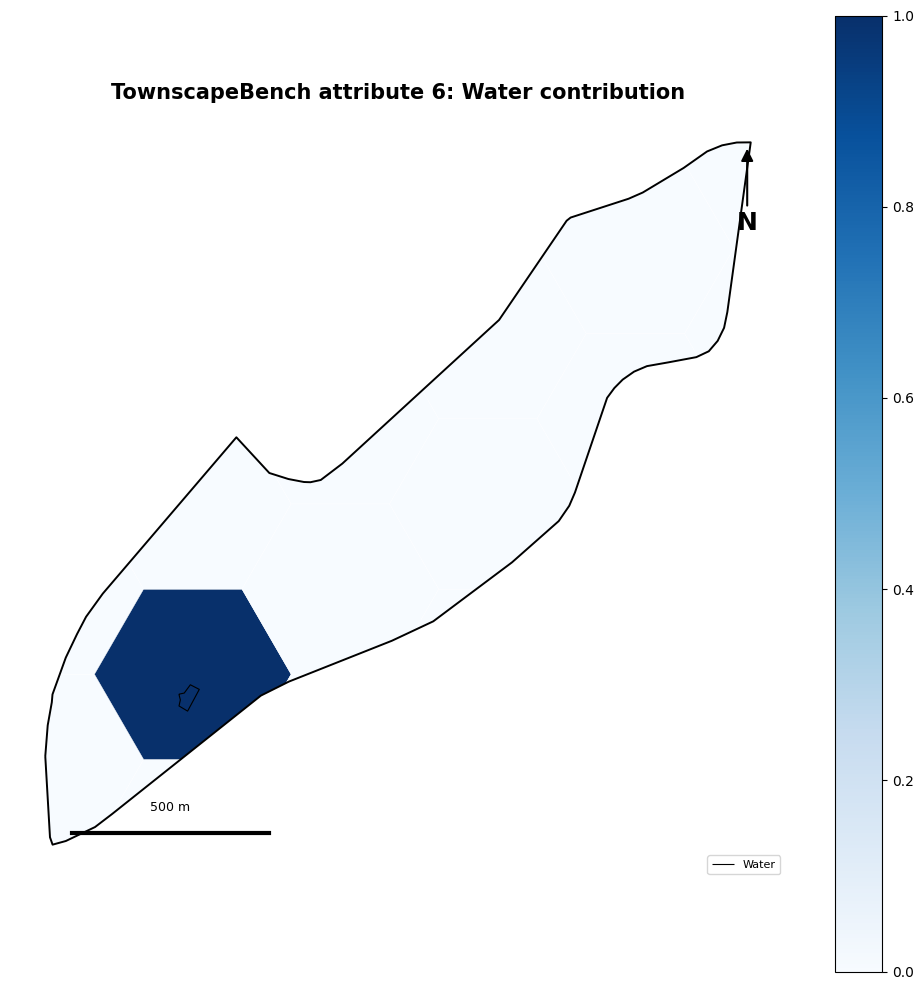

Saved: TownscapeBench_outputs\figures\06_water.png


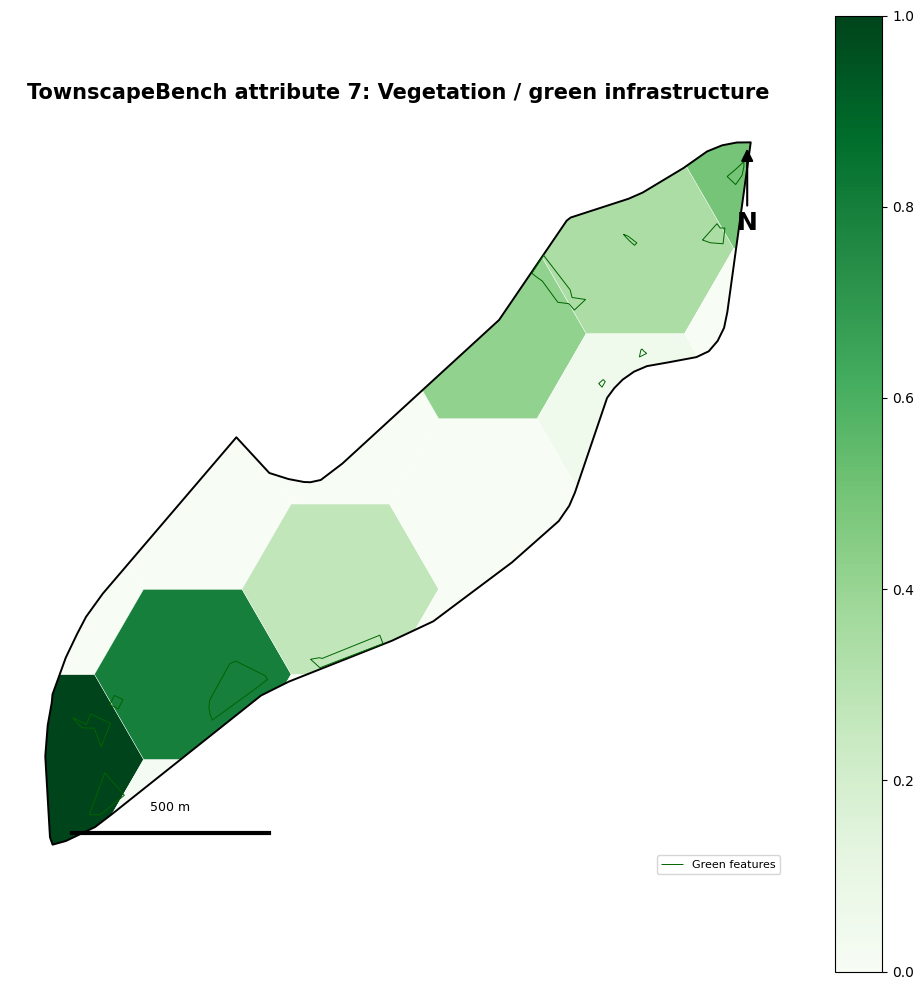

Saved: TownscapeBench_outputs\figures\07_vegetation.png


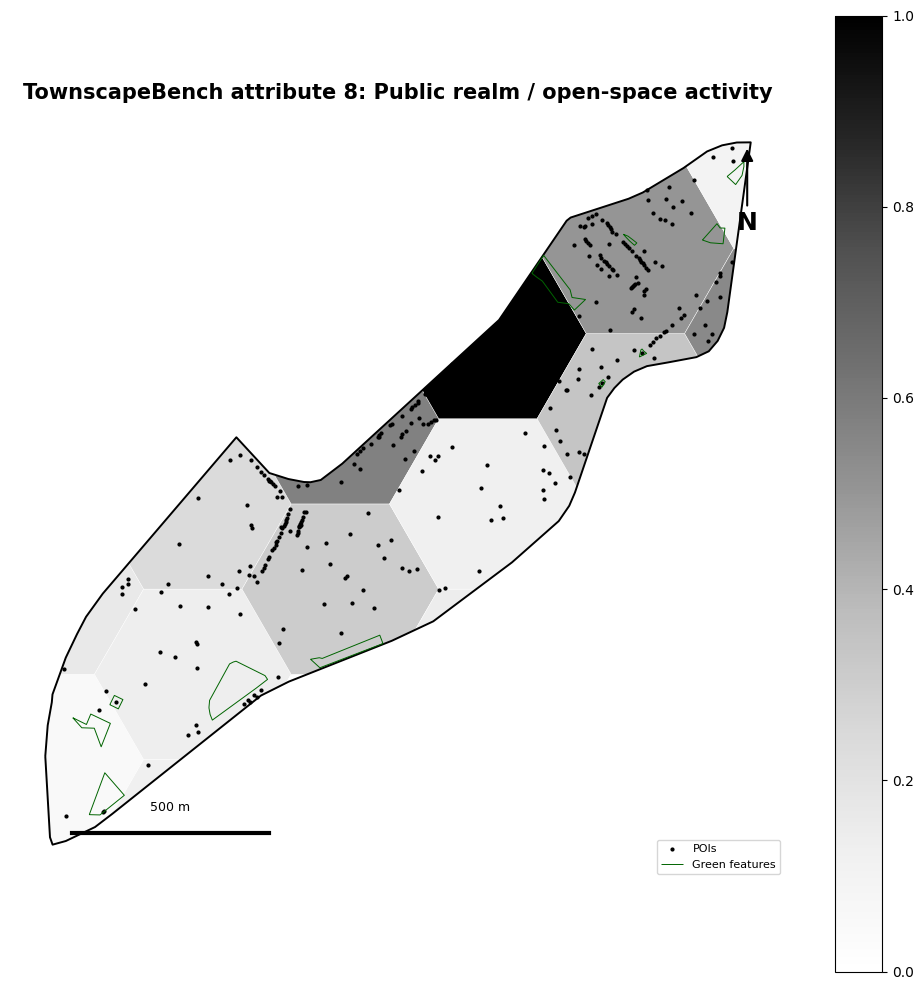

Saved: TownscapeBench_outputs\figures\08_public_realm.png


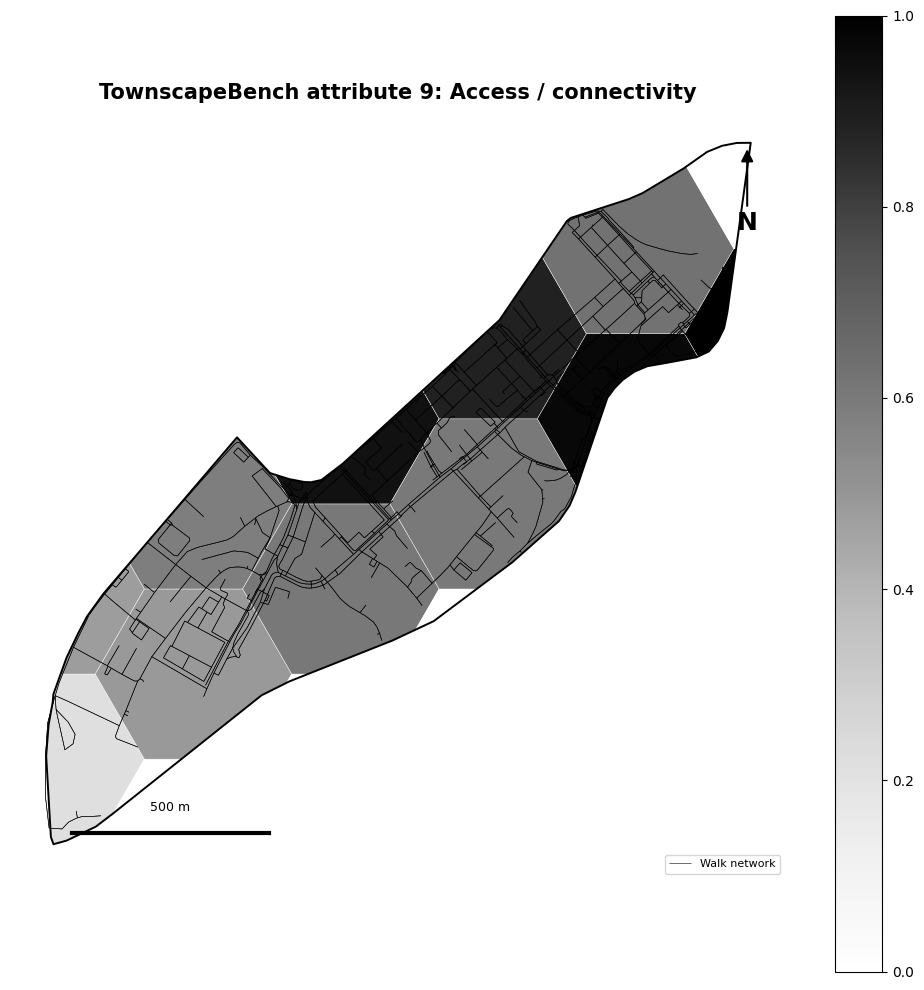

Saved: TownscapeBench_outputs\figures\09_connectivity.png


In [11]:
# ============================================================
# Generate TownscapeBench maps for nine attributes
# ============================================================

# Base overlays
road_overlay = {"gdf": road_lines, "label": "Walk network", "color": "black", "linewidth": 0.4}
building_overlay = {"gdf": buildings_poly.boundary if len(buildings_poly) else buildings_poly, "label": "Buildings", "color": "grey", "linewidth": 0.3}
water_overlay = {"gdf": water_poly, "label": "Water", "color": "black", "linewidth": 0.8}
green_overlay = {"gdf": green_poly, "label": "Green features", "color": "darkgreen", "linewidth": 0.7}
poi_overlay = {"gdf": pois_pts, "label": "POIs", "color": "black", "markersize": 4}

plot_attribute_map(
    metrics_out,
    boundary_proj,
    "context_score",
    "TownscapeBench attribute 1: Context / setting",
    "01_context.png",
    overlays=[road_overlay, poi_overlay],
    cmap="Greys"
)

if metrics_out["topography_score"].notna().any():
    plot_attribute_map(
        metrics_out,
        boundary_proj,
        "topography_score",
        "TownscapeBench attribute 2: Topography",
        "02_topography.png",
        overlays=[road_overlay],
        cmap="terrain"
    )
else:
    print("Topography map skipped because no DEM was available.")

plot_attribute_map(
    metrics_out,
    boundary_proj,
    "grain_score",
    "TownscapeBench attribute 3: Urban grain",
    "03_grain.png",
    overlays=[building_overlay],
    cmap="Greys"
)

plot_attribute_map(
    metrics_out,
    boundary_proj,
    "form_score",
    "TownscapeBench attribute 4: Built form / scale / density",
    "04_form.png",
    overlays=[building_overlay],
    cmap="Greys"
)

plot_attribute_map(
    metrics_out,
    boundary_proj,
    "land_use_score",
    "TownscapeBench attribute 5: Land-use diversity",
    "05_land_use.png",
    overlays=[poi_overlay],
    cmap="Greys"
)

plot_attribute_map(
    metrics_out,
    boundary_proj,
    "water_score",
    "TownscapeBench attribute 6: Water contribution",
    "06_water.png",
    overlays=[water_overlay],
    cmap="Blues"
)

plot_attribute_map(
    metrics_out,
    boundary_proj,
    "vegetation_score",
    "TownscapeBench attribute 7: Vegetation / green infrastructure",
    "07_vegetation.png",
    overlays=[green_overlay],
    cmap="Greens"
)

plot_attribute_map(
    metrics_out,
    boundary_proj,
    "public_realm_score",
    "TownscapeBench attribute 8: Public realm / open-space activity",
    "08_public_realm.png",
    overlays=[poi_overlay, green_overlay],
    cmap="Greys"
)

plot_attribute_map(
    metrics_out,
    boundary_proj,
    "connectivity_score",
    "TownscapeBench attribute 9: Access / connectivity",
    "09_connectivity.png",
    overlays=[road_overlay],
    cmap="Greys"
)

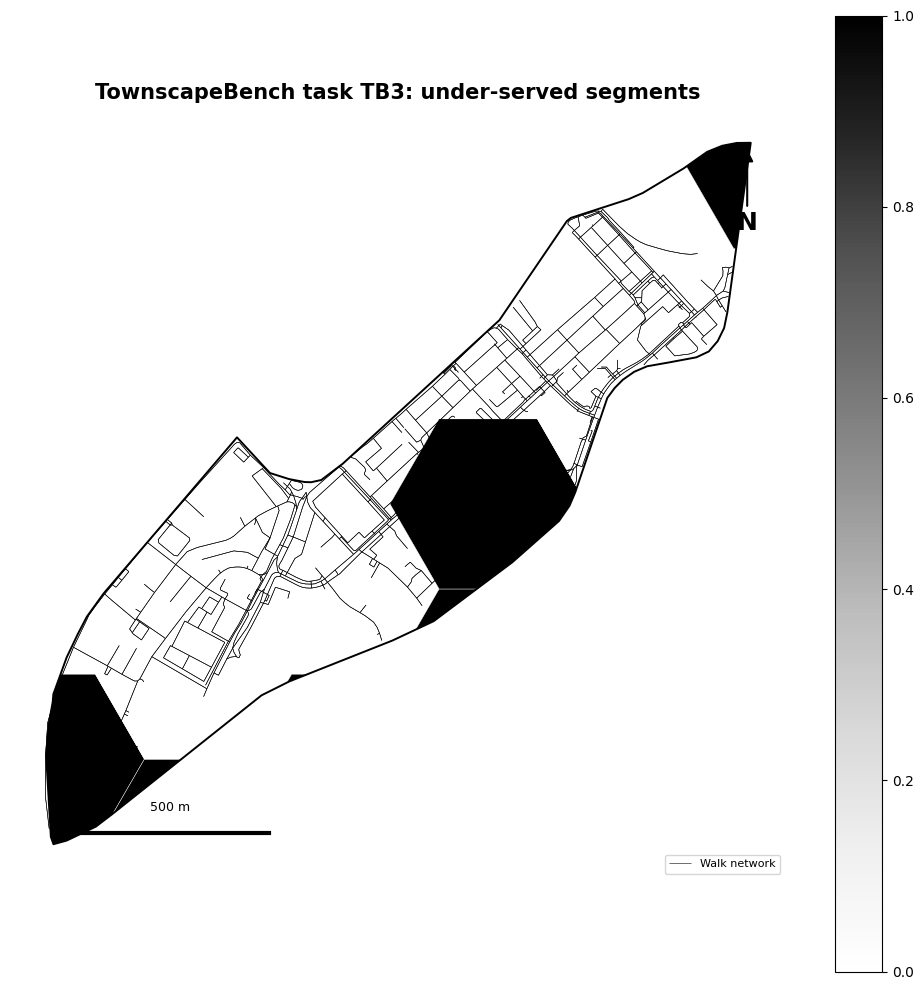

Saved: TownscapeBench_outputs\figures\10_underserved_segments.png
No expert_scores.csv provided. TB1 schema is reported, but model fitting is skipped.


In [12]:
# ============================================================
# TownscapeBench benchmark task demonstration
# TB1, TB2, TB3
# ============================================================

# TB2: estimate quantitative indicators
task_definitions = pd.DataFrame({
    "task_id": ["TB1", "TB2", "TB3"],
    "task_name": [
        "Predict expert townscape scores",
        "Estimate quantitative townscape indicators",
        "Detect under-served or low-performing segments"
    ],
    "input": [
        "Open spatial layers plus optional expert-scored training set",
        "OSM buildings, land use, POIs, water, green features, streets and DEM",
        "TownscapeBench metric table and attribute scores"
    ],
    "output": [
        "Predicted expert score per spatial unit",
        "Nine attribute scores and supporting indicators per spatial unit",
        "Spatial units below selected performance thresholds"
    ],
    "status_in_v01": [
        "Schema provided; requires expert labels for model training",
        "Fully demonstrated in this notebook",
        "Fully demonstrated using percentile-based thresholds"
    ]
})

task_definitions.to_csv(TAB_DIR / "townscapebench_task_definitions.csv", index=False)

# TB3: underserved segments
# Define under-served cells as those below the 25th percentile for public realm or connectivity.
metrics_out["underserved_public_realm"] = metrics_out["public_realm_score"] <= metrics_out["public_realm_score"].quantile(0.25)
metrics_out["underserved_connectivity"] = metrics_out["connectivity_score"] <= metrics_out["connectivity_score"].quantile(0.25)
metrics_out["underserved_any"] = metrics_out["underserved_public_realm"] | metrics_out["underserved_connectivity"]

underserved = metrics_out[metrics_out["underserved_any"]].copy()

underserved[[
    "grid_id",
    "public_realm_score",
    "connectivity_score",
    "underserved_public_realm",
    "underserved_connectivity"
]].to_csv(TAB_DIR / "underserved_segments.csv", index=False)

# map
metrics_out["underserved_score"] = metrics_out["underserved_any"].astype(int)

plot_attribute_map(
    metrics_out,
    boundary_proj,
    "underserved_score",
    "TownscapeBench task TB3: under-served segments",
    "10_underserved_segments.png",
    overlays=[road_overlay],
    cmap="Greys"
)

# Optional TB1: if expert scores exist
EXPERT_SCORE_CSV = Path("expert_scores.csv")

if EXPERT_SCORE_CSV.exists():
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import cross_val_score, KFold
    from sklearn.metrics import mean_absolute_error, r2_score

    expert = pd.read_csv(EXPERT_SCORE_CSV)
    # expected columns: grid_id, expert_score
    train = metrics_out.merge(expert, on="grid_id", how="inner")

    feature_cols = [
        "context_score",
        "grain_score",
        "form_score",
        "land_use_score",
        "water_score",
        "vegetation_score",
        "public_realm_score",
        "connectivity_score"
    ]

    if train["topography_score"].notna().any():
        feature_cols.append("topography_score")

    X = train[feature_cols].fillna(0)
    y = train["expert_score"]

    model = RandomForestRegressor(n_estimators=300, random_state=42)
    cv = KFold(n_splits=min(5, len(train)), shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error")

    model.fit(X, y)
    train["predicted_expert_score"] = model.predict(X)

    tb1_summary = pd.DataFrame({
        "metric": ["n_training_units", "cv_mae_mean", "cv_mae_sd"],
        "value": [len(train), -scores.mean(), scores.std()]
    })

    tb1_summary.to_csv(TAB_DIR / "tb1_expert_score_baseline_summary.csv", index=False)
    train[["grid_id", "expert_score", "predicted_expert_score"]].to_csv(
        TAB_DIR / "tb1_predictions.csv",
        index=False
    )

    print("TB1 expert-score baseline completed.")
else:
    print("No expert_scores.csv provided. TB1 schema is reported, but model fitting is skipped.")

In [13]:
# ============================================================
# TownscapeBench reporting checklist
# ============================================================

checklist = pd.DataFrame({
    "reporting_item": [
        "Study-area boundary",
        "Coordinate reference system",
        "OSM data access date",
        "OSM feature tags",
        "Spatial reporting unit",
        "Hex/grid size",
        "Building indicators",
        "Land-use indicators",
        "Water indicators",
        "Vegetation indicators",
        "Public realm indicators",
        "Connectivity indicators",
        "Topography source",
        "Expert-score availability",
        "Benchmark task outputs",
        "Uncertainty / limitations",
        "Code and CSV availability"
    ],
    "reported_in_v01": [
        "Yes",
        str(CRS_PROJ),
        pd.Timestamp.today().strftime("%Y-%m-%d"),
        "Yes; tags listed in notebook",
        "Hexagonal grid",
        f"{HEX_SIZE_M} m radius",
        "BCR, building density, footprint size, FSI proxy",
        "OSM land-use/amenity diversity",
        "Water fraction",
        "Green fraction",
        "POI density and green/open-space proxies",
        "Walk-network and intersection density",
        "OpenTopography/NASADEM if API key supplied",
        "Optional expert_scores.csv",
        "TB2 and TB3 demonstrated; TB1 schema provided",
        "Reported",
        "GitHub repository and exported CSVs"
    ]
})

checklist.to_csv(TAB_DIR / "townscapebench_reporting_checklist.csv", index=False)
checklist

,reporting_item,reported_in_v01
0,Study-area boundary,Yes
1,Coordinate reference system,EPSG:32647
2,OSM data access date,2026-04-30
3,OSM feature tags,Yes; tags listed in notebook
4,Spatial reporting unit,Hexagonal grid
5,Hex/grid size,250 m radius
6,Building indicators,"BCR, building density, footprint size, FSI proxy"
7,Land-use indicators,OSM land-use/amenity diversity
8,Water indicators,Water fraction
9,Vegetation indicators,Green fraction
